In [18]:
%autoreload 2

In [2]:
%reload_ext autoreload
import numpy as np
import pandas as pd
import sys, os, shutil
from datetime import datetime as dt, timedelta
from fish import Gafftopsail
import utils
from matplotlib import colors
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from PIL import Image

sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')

In [3]:
#AT SOME POINT I MAY BUILD A TANK FOR THIS, ESPECIALLY WHEN IM DEALING WITH NEURON DATA, BUT WE WILL SEE
segment = 13
segment_colname = ['theta_0' + str(i) if i < 10 else 'theta_' + str(i) for i in range(segment)]
frame_range = 30
mama_path = 'C://Users//Zichen//Desktop//250410_dotsweep//0_blackdotonred//'
paths = [mama_path + 'fish' + str(fish_id) + '//' for fish_id in range(1, 9)]
tank = {key: None for key in paths}
bout_dfs = pd.DataFrame()
bout_collections = np.full((0, segment * frame_range), np.nan)
for path in paths:
    try:
        fish = Gafftopsail(path, ['stimulus', 'tail', 'eye', 'processed_tail', 'processed_eye'])
        tank[path] = fish
        bout_df = fish.bout_df
        tail_df = fish.tail_df.copy()#CLUSTERING THE Z SCORED TAIL-DF
        tail_df.loc[:, segment_colname] = np.divide(np.subtract(tail_df[segment_colname], np.mean(tail_df[segment_colname], axis = 0)), np.std(tail_df[segment_colname], axis = 0))
        tail_start_index = [i[0] for i in bout_df.cont_tuples_tailindex]
        for bout_start in tail_start_index:
            bout_collection = tail_df.iloc[bout_start:bout_start + frame_range].loc[:, segment_colname].to_numpy().flatten()
            bout_collections = np.append(bout_collections, [bout_collection], axis=0)
        bout_df.loc[:, 'fish'] = [path.split('//')[-2]] * len(bout_df)
        bout_dfs = pd.concat([bout_dfs, bout_df], axis = 0)
    except FileNotFoundError: pass

In [5]:
bout_dfs.loc[:, 'tail_realstimuli'] = [str(i) for i in bout_dfs['tail_realstimuli']]
bout_dfs.loc[:, 'tail_stimuli'] = [str(i) for i in bout_dfs['tail_stimuli']]
bout_dfs.loc[:, 'fish_num'] = [int(i.split('h')[1].split('_')[0]) for i in bout_dfs['fish']]

In [7]:
fish.stimulus_df.stim_name.unique()

array(['dot_r_cls_l', 'dot_r_far_l', 'dot_r_cls_s', 'dot_l_cls_s',
       'dot_l_far_l', 'dot_l_cls_l', 'dot_r_far_s', 'dot_l_far_s'],
      dtype=object)

In [8]:
omr_stim = [i for i in fish.stimulus_df.stim_name.unique() if 'dot' not in i and '[' not in i]
dot_stim = [i for i in fish.stimulus_df.stim_name.unique() if 'dot' in i and '[' not in i]
overlap_stim = [i for i in fish.stimulus_df.stim_name.unique() if '[' in i]

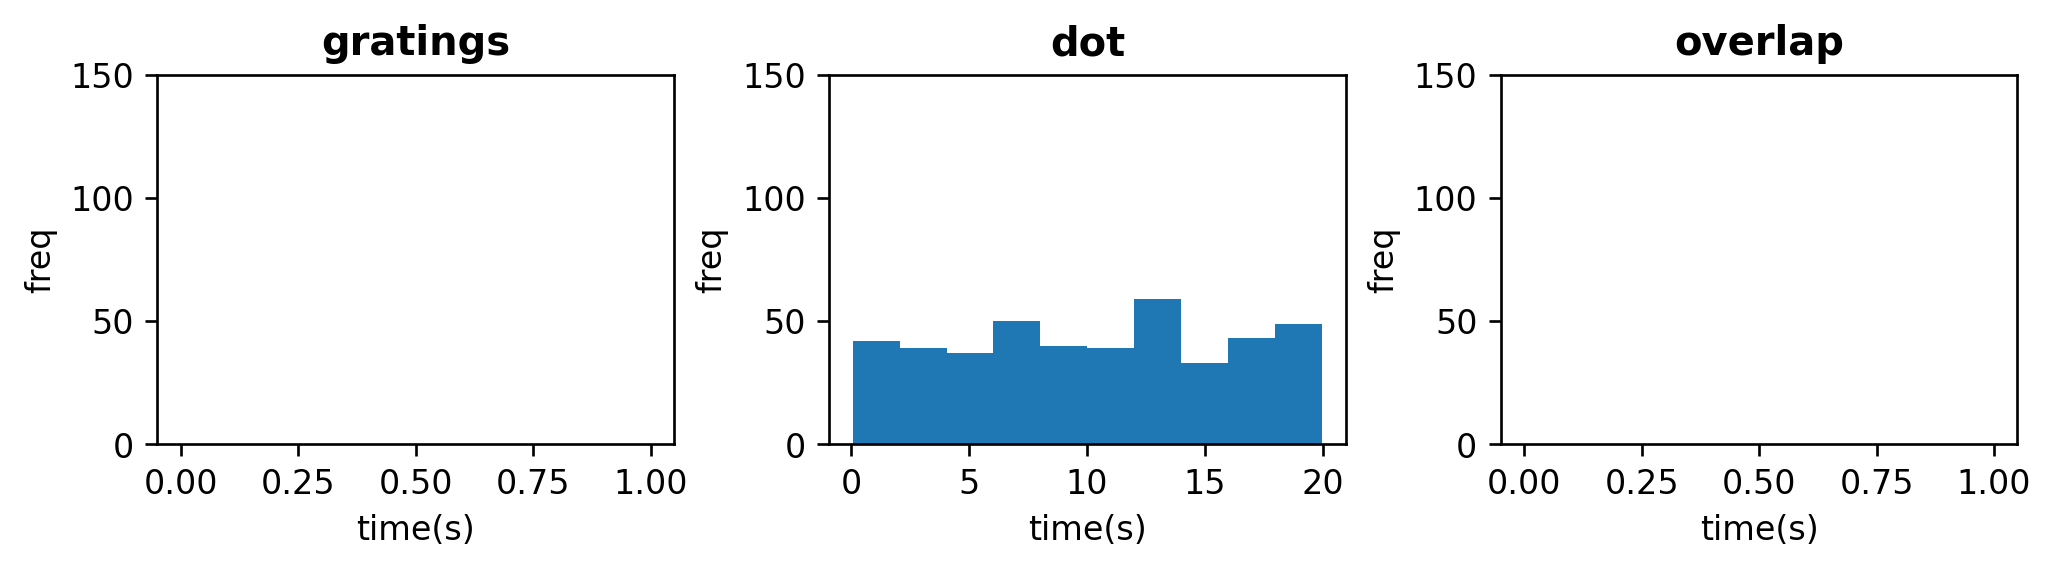

In [12]:
def fix_ax(ax, title):
    ax.set_title(title, weight = 'bold')
    ax.grid(False)
    ax.set_xlabel('time(s)')
    ax.set_ylabel('freq')
    ax.set_ylim(0, 150)
fig, ax = plt.subplots(1, 3, figsize = (10, 2), dpi = 240, gridspec_kw={'wspace': 0.3})
#not overlapping trials even grating is the only moving part
ax[0].hist(bout_dfs[(bout_dfs['tail_stimuli'].isin(omr_stim)) & (bout_dfs['tail_stimuli'].isin(omr_stim))].tail_fromstart_s, linewidth = 0)
fix_ax(ax[0], 'gratings')

ax[1].hist(bout_dfs[(bout_dfs['tail_stimuli'].isin(dot_stim)) & (bout_dfs['tail_stimuli'].isin(dot_stim))].tail_fromstart_s, linewidth = 0)
fix_ax(ax[1], 'dot')

ax[2].hist(bout_dfs[(bout_dfs['tail_stimuli'].isin(overlap_stim)) & (bout_dfs['tail_stimuli'].isin(overlap_stim))].tail_fromstart_s, linewidth = 0)
fix_ax(ax[2], 'overlap')

In [14]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(bout_collections)

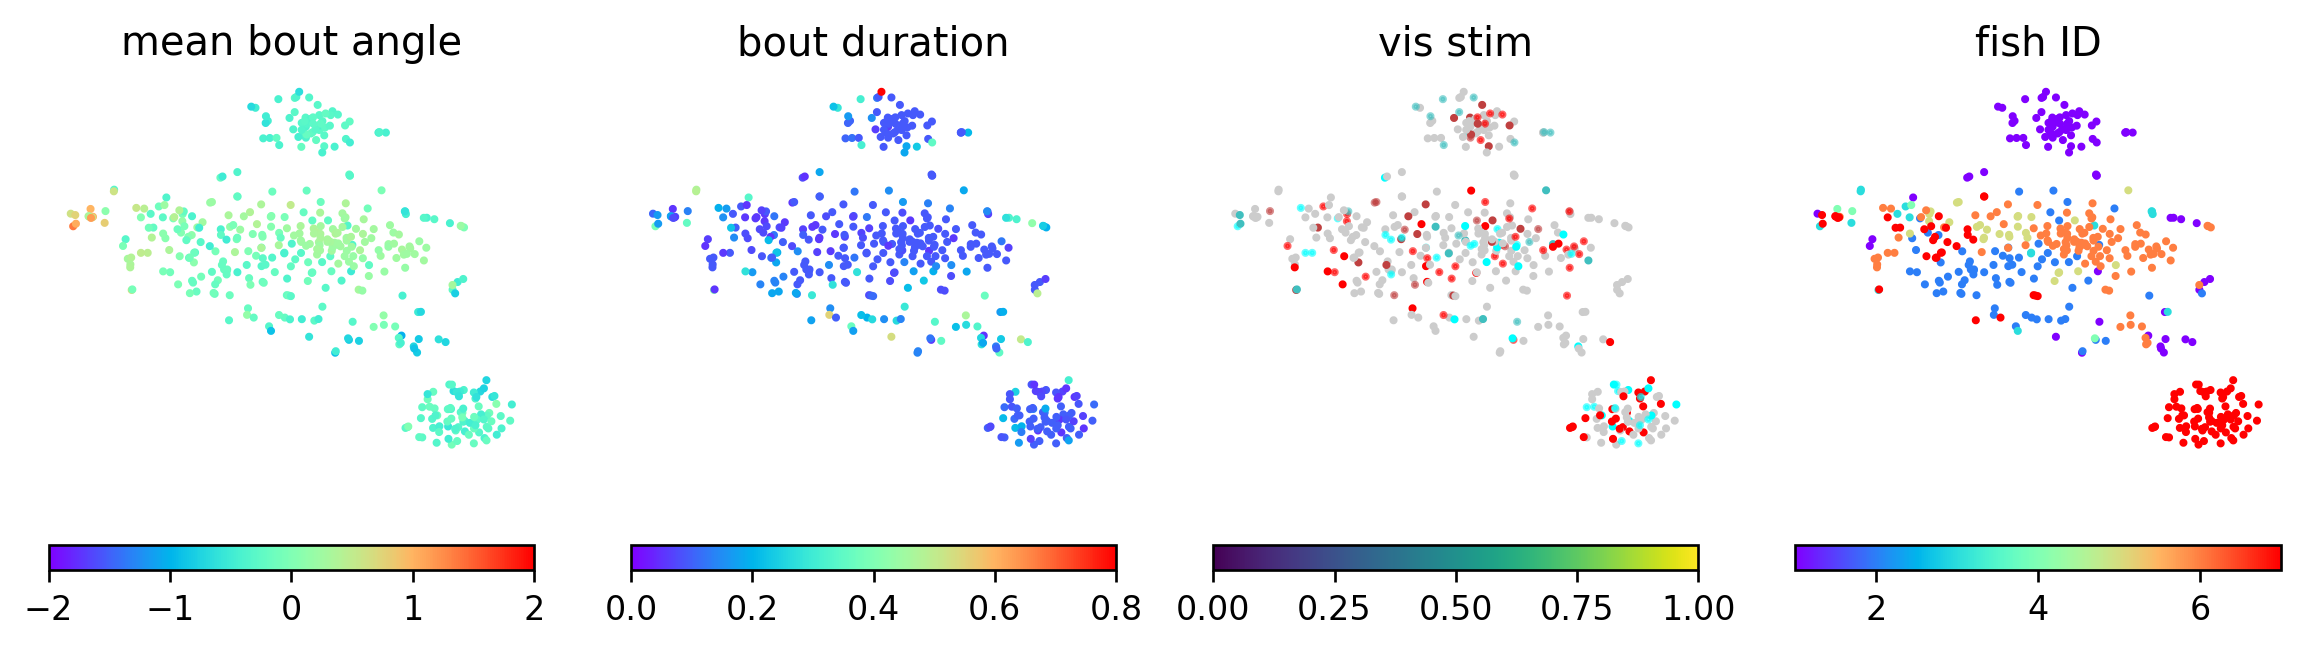

In [19]:
def fix_ax(ax, title):
    ax.set_title(title)
    ax.axis('off')
fig, ax = plt.subplots(1, 4, figsize = (12, 3), dpi = 240)

plot_scatter = ax[0].scatter(X_embedded[:, 0], X_embedded[:, 1], c=bout_dfs['tail_angle'], vmin = -2, vmax = 2, cmap='rainbow', s = 2)
plt.colorbar(plot_scatter, ax = ax[0], location = 'bottom')
fix_ax(ax[0], 'mean bout angle')

plot_scatter = ax[1].scatter(X_embedded[:, 0], X_embedded[:, 1], c=bout_dfs['tail_duration_s'], vmin = 0, vmax = 0.8, cmap='rainbow', s = 2)
plt.colorbar(plot_scatter, ax = ax[1], location = 'bottom')
fix_ax(ax[1], 'bout duration')

plot_scatter = ax[2].scatter(X_embedded[:, 0], X_embedded[:, 1], c=[utils.dot_colors[i] for i in bout_dfs['tail_realstimuli']], s = 2)
plt.colorbar(plot_scatter, ax = ax[2], location = 'bottom')
fix_ax(ax[2], 'vis stim')

plot_scatter = ax[3].scatter(X_embedded[:, 0], X_embedded[:, 1], c=bout_dfs['fish_num'], cmap = 'rainbow', s = 2)
plt.colorbar(plot_scatter, ax = ax[3], location = 'bottom')
fix_ax(ax[3], 'fish ID')

In [20]:
import dash
import dash_core_components as dcc
import dash.html as html
from dash.dependencies import Input, Output
import plotly.graph_objects as go
from jupyter_dash import JupyterDash


C:\Users\Zichen\AppData\Local\Temp\ipykernel_24368\2491904134.py:2: UserWarning: 
The dash_core_components package is deprecated. Please replace
`import dash_core_components as dcc` with `from dash import dcc`
  import dash_core_components as dcc


In [23]:
#@CHATGPT
scatter = go.Scatter(x = X_embedded[:, 0], y = X_embedded[:, 1], mode = 'markers', marker = dict(size = 3, color = [utils.dot_colors[i] for i in bout_dfs['tail_stimuli']], colorscale = 'Portland'),  text=['bout_row:' + str(i) for i in range(len(X_embedded))], hoverinfo="text")
# Layout for the app
app = dash.Dash(__name__)

app.layout = html.Div([
    dcc.Graph(id='scatter-plot', figure={'data': [scatter], 'layout': go.Layout(title='tSNE Result')} ),
    dcc.Graph(id='heatmap', figure={'data': [], 'layout': go.Layout(title='Heatmap')})])

# Callback to update heatmap based on scatter plot point click
@app.callback(
    Output('heatmap', 'figure'),
    [Input('scatter-plot', 'clickData')])
def update_heatmap(clickData):
    if clickData is None:
        # If no point is clicked, return an empty figure or a default heatmap
        return {'data': [], 'layout': go.Layout(title='Bout')}
    # Get the index from the clicked point in scatter plot (which corresponds to df_b['index_in_c'])
    bout_row = int(clickData['points'][0]['text'].split('bout_row:')[1])
    bout_index = bout_dfs.iloc[bout_row]['cont_tuples_tailindex']
    stim = bout_dfs.iloc[bout_row]['tail_realstimuli']
    fish_id = bout_dfs.iloc[bout_row]['fish']
    fish = tank[mama_path + fish_id + '//']
    bout_index = [max(0, bout_index[0]-50), min(len(fish.tail_df), bout_index[1] + 50)]#take before and after 10 frames
    # Create a heatmap figure
    heatmap_fig = go.Figure(
        data=go.Heatmap(z=fish.tail_df.iloc[bout_index[0]:bout_index[1]].loc[:, segment_colname].T, colorscale='balance', zmin = -1.5, zmax = 1.5),
        layout=go.Layout(title='#bout' + str(bout_row) + ' #' + str(fish_id) + ' #' + stim ))
    return heatmap_fig

# Run the app
app.run_server(debug=True, jupyter_mode = 'tab')

Dash app running on http://127.0.0.1:8050/


<IPython.core.display.Javascript object>